In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
df = pd.read_csv("dataset.csv")

In [3]:
df

,student_id,age,gender,category,state,preferred_stream,entrance_exam,entrance_score,board_percentage,extracurricular_score,admission_probability,admission_status,scholarship_eligibility
0,250.99,17,other,general,odisha,management,cet,30,95.58,2,0.387,admitted,yes
1,250.99,20,other,ews,gujarat,agriculture,none,0,75.45,2,0.221,rejected,no
2,250.99,19,female,sc,uttar pradesh,pharmacy,cet,120,75.36,10,0.446,rejected,no
3,250.99,18,male,ews,meghalaya,arts,cet,179,52.49,2,0.174,admitted,no
4,250.99,18,male,sc,rajasthan,engineering,jee,295,92.48,7,0.634,admitted,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,24750.01,18,female,obc,uttar pradesh,law,none,0,82.67,2,0.273,rejected,no
24996,24750.01,20,other,ews,andhra pradesh,management,none,0,60.66,10,0.258,rejected,no
24997,24750.01,17,male,obc,manipur,pharmacy,cet,195,91.87,6,0.544,rejected,no
24998,24750.01,19,male,ews,andhra pradesh,management,cet,66,50.44,9,0.209,rejected,no


In [4]:
df = df[df["entrance_exam"] == "cet"]

In [5]:
df = df[["entrance_score"]]

In [6]:
df

,entrance_score
0,30
2,120
3,179
6,57
9,125
...,...
24990,138
24992,22
24994,146
24997,195


In [19]:
df.describe()

,entrance_score
count,10433.000000
mean,99.970478
std,58.084934
min,0.000000
25%,49.000000
50%,101.000000
75%,150.000000
max,199.000000


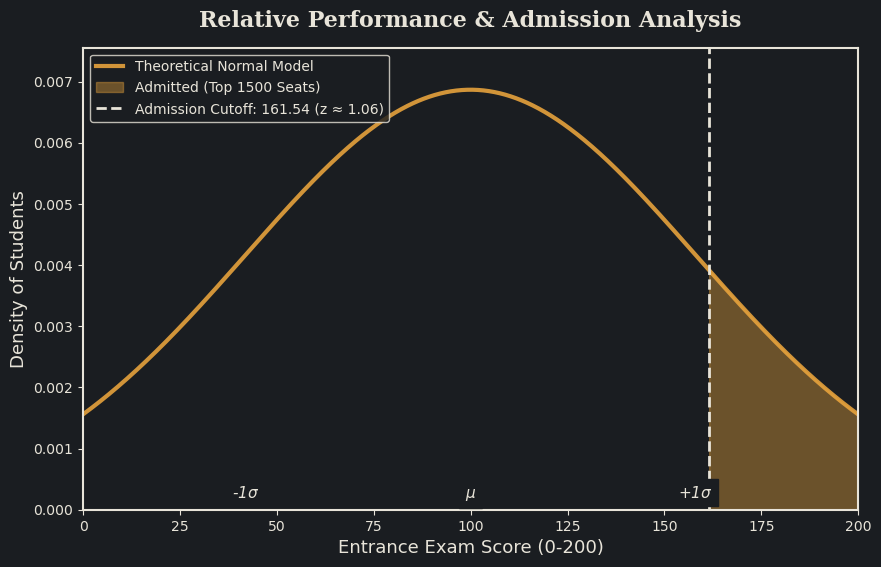

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

mu = df["entrance_score"].mean()
sigma = df["entrance_score"].std()
max_score_limit = 200
min_score_limit = 0
seats = 1500
total_students = 10433

cutoff_score = mu + (1.06 * sigma) 

chalk_white = '#E8E4D9'
chalk_amber = '#E6A23C'
background_color = '#1A1D21'

plt.figure(figsize=(10, 6), facecolor=background_color)
ax = plt.gca()
ax.set_facecolor(background_color)

for spine in ax.spines.values():
    spine.set_color(chalk_white)
    spine.set_linewidth(1.5)
ax.tick_params(axis='x', colors=chalk_white)
ax.tick_params(axis='y', colors=chalk_white)

x = np.linspace(min_score_limit, max_score_limit, 1000)
y = stats.norm.pdf(x, mu, sigma)
plt.plot(x, y, label='Theoretical Normal Model', color=chalk_amber, lw=3, alpha=0.9)

x_admission = np.linspace(cutoff_score, max_score_limit, 100)
y_admission = stats.norm.pdf(x_admission, mu, sigma)
plt.fill_between(x_admission, y_admission, color=chalk_amber, alpha=0.4, label='Admitted (Top 1500 Seats)')

z_val = (cutoff_score - mu) / sigma
plt.axvline(cutoff_score, color=chalk_white, linestyle='--', linewidth=2, 
            label=f'Admission Cutoff: {cutoff_score:.2f} (z ≈ {z_val:.2f})')

plt.title('Relative Performance & Admission Analysis', color=chalk_white, fontsize=16, fontweight='bold', fontfamily='serif', pad=15)
plt.xlabel('Entrance Exam Score (0-200)', color=chalk_white, fontsize=13)
plt.ylabel('Density of Students', color=chalk_white, fontsize=13)
plt.legend(facecolor=background_color, edgecolor=chalk_white, labelcolor=chalk_white, loc='upper left')


sd_positions = [mu, mu + 1*sigma, mu + 2*sigma, mu - 1*sigma]
sd_labels = [r'$\mu$', r'+1$\sigma$', r'+2$\sigma$', r'-1$\sigma$']

for pos, label in zip(sd_positions, sd_labels):
    if min_score_limit <= pos <= max_score_limit:
        plt.text(pos, 0.0002, label, color=chalk_white, ha='center', 
                 fontsize=11, style='italic', backgroundcolor=background_color)

plt.xlim(min_score_limit, max_score_limit)
plt.ylim(0, max(y) * 1.1)
plt.grid(False)

plt.show()